In [2]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 

## Flavor


In [ ]:
# Auflösungsvermögen
# Spallt_breite = np.array([1]) # mm

# lambda_b = np.array([208.5-204.4, 211.00-201.4, 213.63-199.4])
# lambda_gr = np.array([209.2-203.71, 212.35-200.55, 215.80-197.25])
# lambda_ge = np.array([209.65-203.21, 212.66-200.2, 216.00-196.4])

Spalt_b_r = np.array([2.75, 1.24, 1]) # mm
Spalt_b_l = np.array([2.61, 1.1, 0.80]) #mm
n = np.array([1,2,3])
Spalt_b_l_u = unp.uarray(Spalt_b_l,0.05)
Spalt_b_r_u = unp.uarray(Spalt_b_r,0.05)

la_1 = 576.96 # nm
la_2 = 579.07 # nm

del_la = la_2-la_1
print(del_la)
A = la_1/del_la
print(f"Auflösungsvermögen: {A}")

def gitter(n, B, A):
    return n*B/A

d_l = gitter(n,Spalt_b_l, A)
d_r = gitter(n,Spalt_b_r,A)
d_all = np.append(d_l,d_r)
d_m = np.mean(d_all)
print(f"Alle Werte für d:{d_all}")
print(f"Mittelwert {d_m}")
print(f"Standardabweichung des Mittelwerts: {(1/np.sqrt(5))*np.std(d_all)}") #Standardabweichung Mittelwert

2.1100000000000136
Auflösungsvermögen: 273.4407582938371
Alle Werte für d:[0.00954503 0.00804562 0.00877704 0.01005702 0.00906961 0.0109713 ]
Mittelwert 0.009410935477907252
Standardabweichung des Mittelwerts:0.00041843211032513655


## Flavor

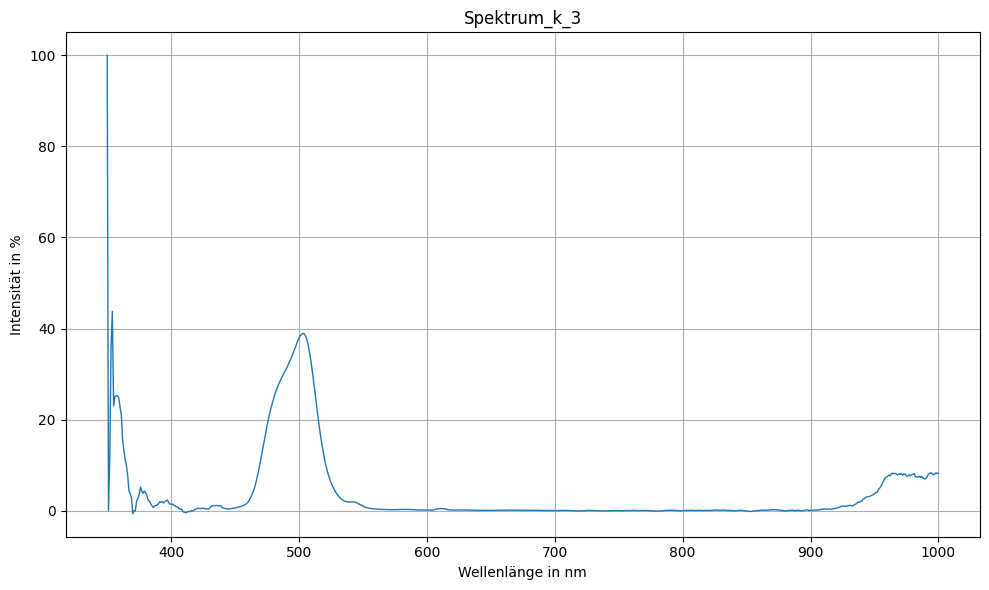

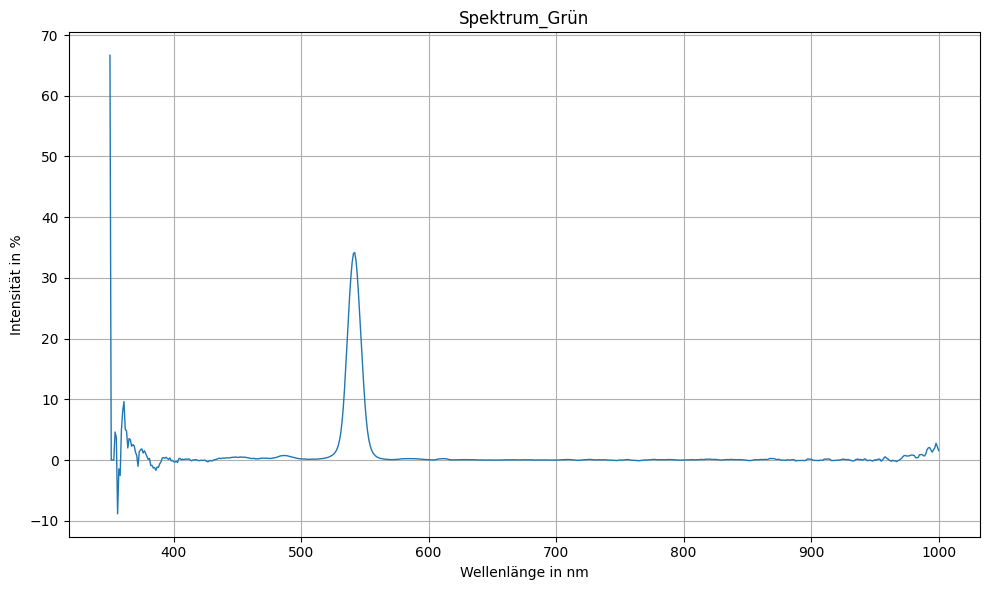

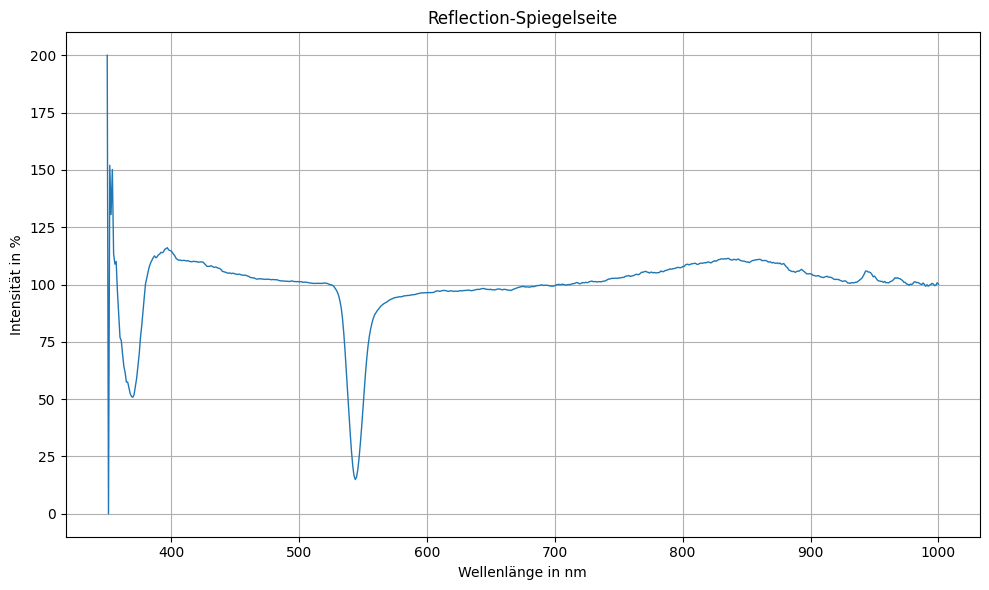

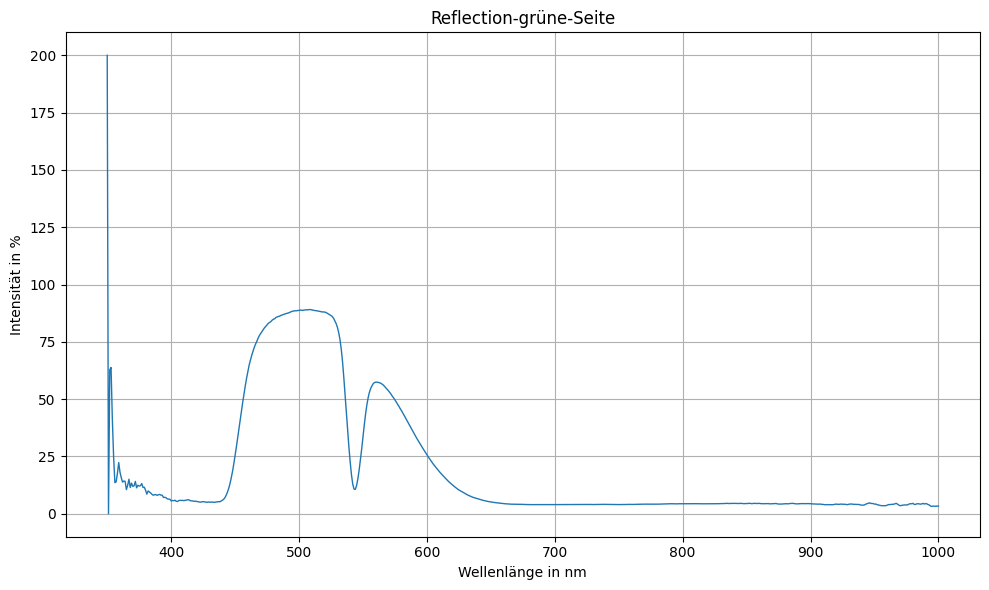

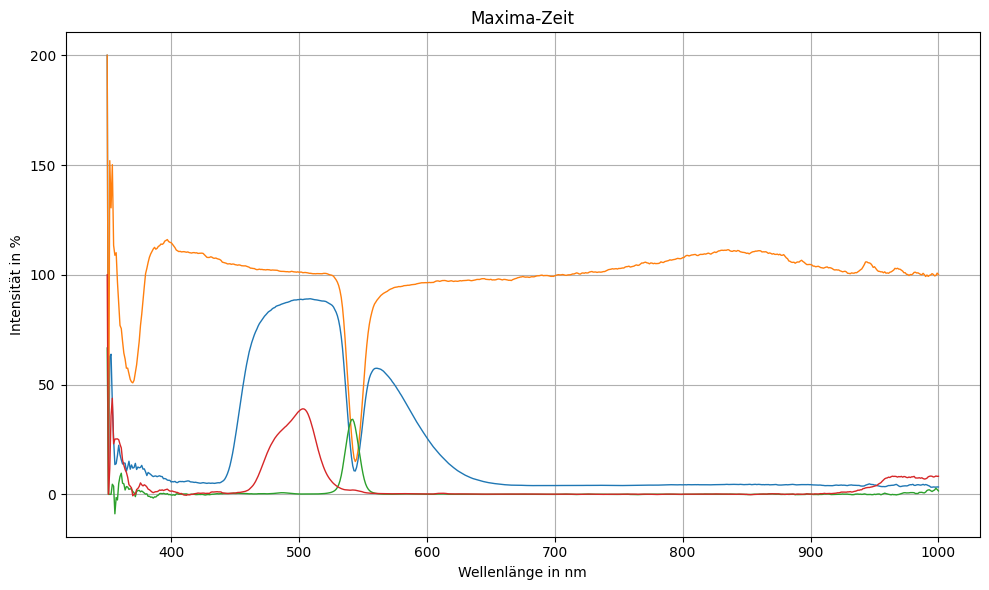

: 

In [ ]:
# Spektroskopie
"""
Hierbei ist wchtig zu erwähnen, dass OceanView die csv-Datei richtig Scheiße ausgibt.
Ich habe diese intern mittels Strg + f und dem Ersetzungstool von VS-Code verändert und Werte unter 0 auf 0 gesetzt.
"," => "."
"Diese komischen Leerzeichen" => ","
"""
# new Data
Spektrum_k_3 = pd.read_csv("Transmission-k-3.txt", sep=',', decimal='.')


l_3 = Spektrum_k_3["l"].to_numpy()

I_3 = Spektrum_k_3["I"].to_numpy()


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(l_3, I_3, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Spektrum_k_3")
plt.grid()
plt.tight_layout()

# new Data
Spektrum_green = pd.read_csv("Transmission-green.txt", sep=',', decimal='.')


l_g = Spektrum_green["l"].to_numpy()

I_g = Spektrum_green["I"].to_numpy()


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(l_g, I_g, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Spektrum_Grün")
plt.grid()
plt.tight_layout()

Spektrum_mir = pd.read_csv("Reflection-spiegel.txt", sep=',', decimal='.')


l_m = Spektrum_mir["l"].to_numpy()

I_m = Spektrum_mir["I"].to_numpy()


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(l_m, I_m, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Reflection-Spiegelseite")
plt.grid()
plt.tight_layout()


Spektrum_greed = pd.read_csv("Reflection-green.txt", sep=',', decimal='.')


l = Spektrum_greed["l"].to_numpy()

I = Spektrum_greed["I"].to_numpy()


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(l, I, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Reflection-grüne-Seite")
plt.grid()
plt.tight_layout()


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(l, I, '-', linewidth=1)
plt.plot(l_m, I_m, '-', linewidth=1)
plt.plot(l_g, I_g, '-', linewidth=1)
plt.plot(l_3, I_3, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Maxima-Zeit")
plt.grid()
plt.tight_layout()


## Flavor

[5.00000000e-06 2.50496000e-01 5.00572000e-01 ... 3.73044367e+02
 3.73277022e+02 3.73544676e+02]
12.03


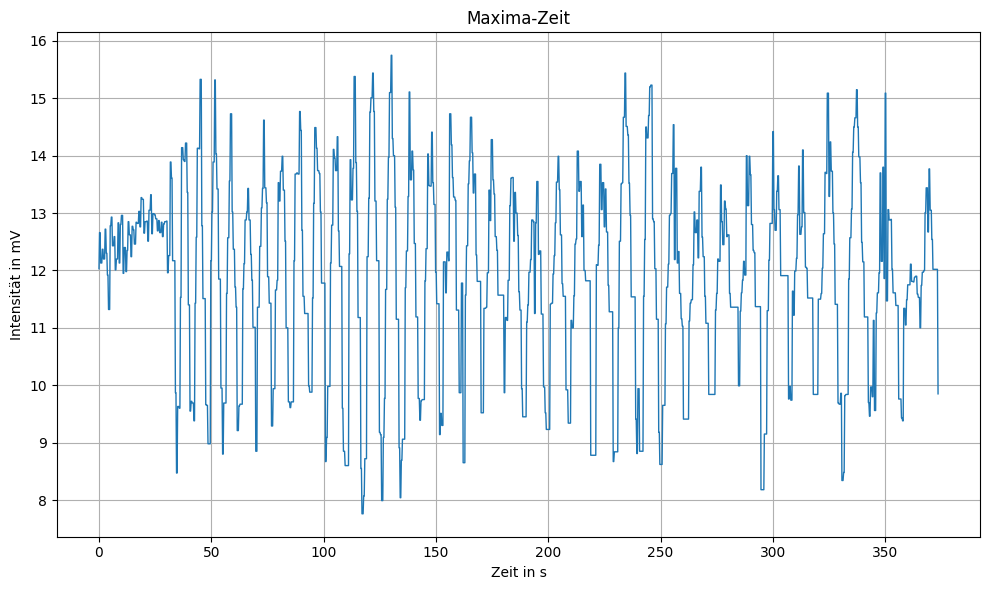

: 

In [ ]:
# Michelson

T_s = 24.6 #°C
T_e = 32.3 #°C
lam = 632.8 # nm

# new Data
Welle = pd.read_csv("molly.txt", sep=',', decimal='.')


t = Welle["t"].to_numpy()
print(t)

I = Welle["I"].to_numpy()

print(I[0])


def alp():
    pass

# mask = np.isfinite(E) & np.isfinite(N)
# E, N = E[mask], N[mask]


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(t, I, '-', linewidth=1)
plt.xlabel("Zeit in s")
plt.ylabel("Intensität in mV")
plt.title("Maxima-Zeit")
plt.grid()
plt.tight_layout()